# Harrod-Domar Model: Singapore vs Bangladesh (2004–2023)

**Name:** Raihan Sadath  
**Register No:** 2333442  
**Course:** ECO208-3 — Fundamentals of Economic Growth and Development  
**Institution:** Christ (Deemed to Be University), Bengaluru 

---

## What is the Harrod-Domar Model?

The Harrod-Domar model is a foundational Keynesian growth model developed independently by Roy Harrod (1939) and Evsey Domar (1946). It explains economic growth through two variables:

$$g = \frac{s}{v}$$

Where:
- **g** = GDP growth rate
- **s** = Gross Domestic Savings rate (% of GDP)
- **v** = Capital-Output Ratio = Gross Capital Formation / GDP growth

**Core insight:** Higher savings → more investment → more capital → higher growth.

---

## Data Source

World Bank Open Data (2004–2023) for Singapore and Bangladesh:
- `NY.GDP.MKTP.KD.ZG` — GDP growth rate (annual %)
- `NY.GDS.TOTL.ZS` — Gross Domestic Savings (% of GDP)
- `NE.GDI.TOTL.ZS` — Gross Capital Formation (% of GDP)

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f9f9f9',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'grid.linestyle':   '--',
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

SGP_COLOR  = '#1a6faf'
BGD_COLOR  = '#c0392b'
SAV_COLOR  = '#e74c3c'
CAP_COLOR  = '#2c3e50'
TREND_ALPHA = 0.35

print('Libraries loaded ✓')

Libraries loaded ✓


In [11]:
# ── Load & filter data ─────────────────────────────────────────────────────
df_raw = pd.read_excel('data.xlsx')
df = df_raw[(df_raw['Year'] >= 2004) & (df_raw['Year'] <= 2023)].copy()
df.reset_index(drop=True, inplace=True)

# Harrod-Domar warranted growth rate: g = s / v  (v = capital / growth)
# We use s/capital as a proxy for the warranted growth rate index
df['SGP_hd'] = df['SGP_savings'] / df['SGP_capital']
df['BGD_hd'] = df['BGD_savings'] / df['BGD_capital']

print(df[['Year','SGP_growth','SGP_savings','SGP_capital','BGD_growth','BGD_savings','BGD_capital']].to_string(index=False))

 Year  SGP_growth  SGP_savings  SGP_capital  BGD_growth  BGD_savings  BGD_capital
 2004    4.548255    43.050555    17.224525    4.739567    20.185622    24.679189
 2005    9.939983    47.682904    22.892462    5.239533    21.187913    24.991834
 2006    7.366322    50.254979    21.506936    6.535945    21.055714    25.830436
 2007    9.006766    51.986968    22.379263    6.671905    21.436613    26.144146
 2008    9.021520    54.097909    23.065953    7.058599    20.747384    26.178497
 2009    1.863483    49.935862    30.159676    6.013790    19.189412    26.202271
 2010    0.127953    50.967105    27.370115    5.045125    20.332414    26.206057
 2011   14.519750    53.970593    27.658228    5.571788    20.810024    26.246656
 2012    6.214934    54.147547    26.691994    6.464379    20.622084    27.420973
 2013    4.435498    53.836085    29.262943    6.521459    21.223763    28.262335
 2014    4.817631    52.922322    29.979502    6.013606    22.036094    28.389621
 2015    3.93554

---
## 1 — Singapore: GDP Growth Rate (2004–2023)

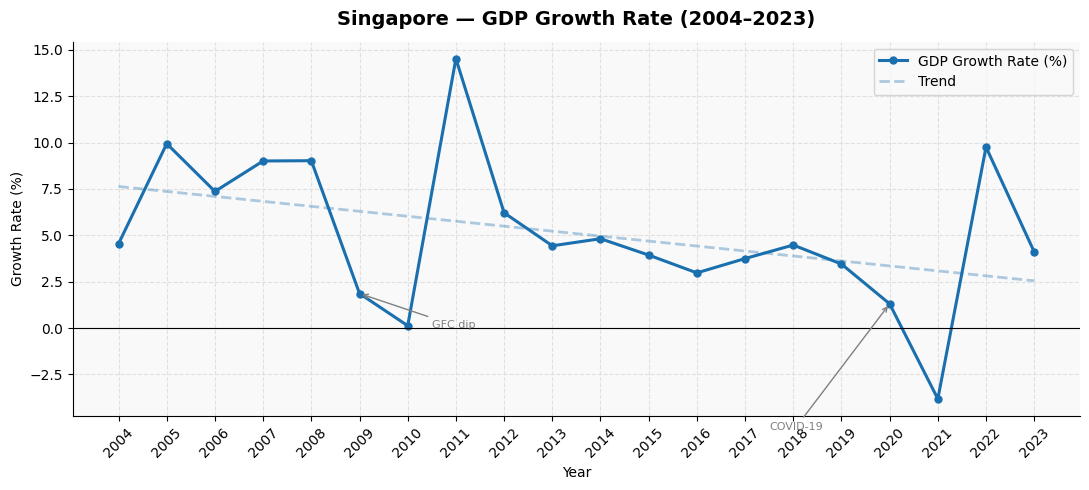

In [12]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(df['Year'], df['SGP_growth'], color=SGP_COLOR, linewidth=2.2,
        marker='o', markersize=5, label='GDP Growth Rate (%)')

# Trend line
z = np.polyfit(df['Year'], df['SGP_growth'], 1)
ax.plot(df['Year'], np.poly1d(z)(df['Year']),
        '--', color=SGP_COLOR, alpha=TREND_ALPHA, linewidth=2, label='Trend')

# Annotate notable events
ax.annotate('GFC dip', xy=(2009, df.loc[df['Year']==2009,'SGP_growth'].values[0]),
            xytext=(2010.5, 0), fontsize=8, color='grey',
            arrowprops=dict(arrowstyle='->', color='grey', lw=1))
ax.annotate('COVID-19', xy=(2020, df.loc[df['Year']==2020,'SGP_growth'].values[0]),
            xytext=(2017.5, -5.5), fontsize=8, color='grey',
            arrowprops=dict(arrowstyle='->', color='grey', lw=1))

ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax.set_title('Singapore — GDP Growth Rate (2004–2023)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Growth Rate (%)')
ax.set_xticks(df['Year'])
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('sgp_growth.png', dpi=150)
plt.show()

**Observation:** Singapore's GDP growth shows high volatility, heavily influenced by external shocks (2009 GFC, 2020 COVID). Despite this, the long-run trend is upward, reflecting a resilient, export-driven economy.

---
## 2 — Singapore: Savings vs Capital Formation

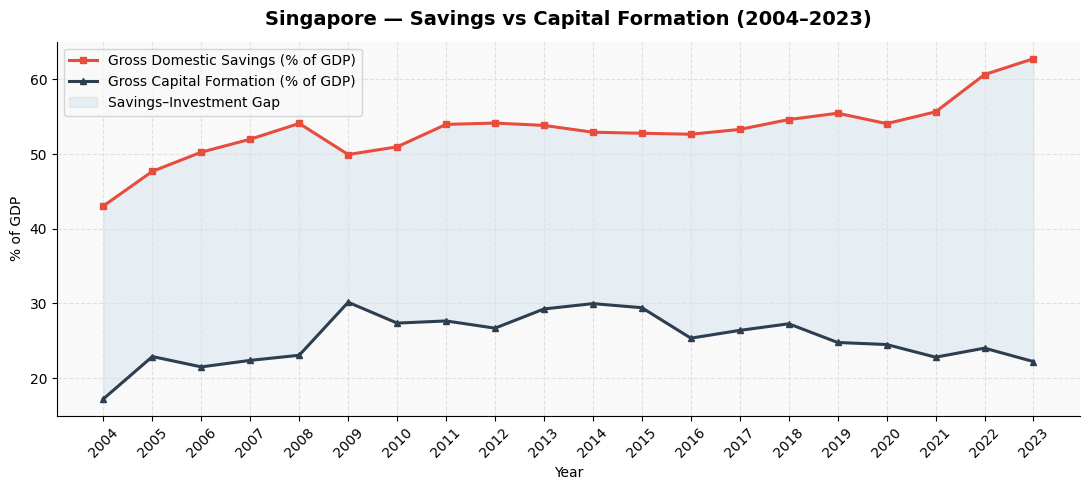

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(df['Year'], df['SGP_savings'], color=SAV_COLOR, linewidth=2.2,
        marker='s', markersize=5, label='Gross Domestic Savings (% of GDP)')
ax.plot(df['Year'], df['SGP_capital'], color=CAP_COLOR, linewidth=2.2,
        marker='^', markersize=5, label='Gross Capital Formation (% of GDP)')

ax.fill_between(df['Year'], df['SGP_savings'], df['SGP_capital'],
                alpha=0.08, color=SGP_COLOR, label='Savings–Investment Gap')

ax.set_title('Singapore — Savings vs Capital Formation (2004–2023)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('% of GDP')
ax.set_xticks(df['Year'])
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('sgp_cs.png', dpi=150)
plt.show()

**Observation:** Singapore's savings rate (~50–60% of GDP) consistently exceeds its capital formation (~22–30%), meaning it generates far more savings than it invests domestically. This surplus is channelled into foreign assets and sovereign wealth funds (GIC, Temasek).

---
## 3 — Bangladesh: GDP Growth Rate (2004–2023)

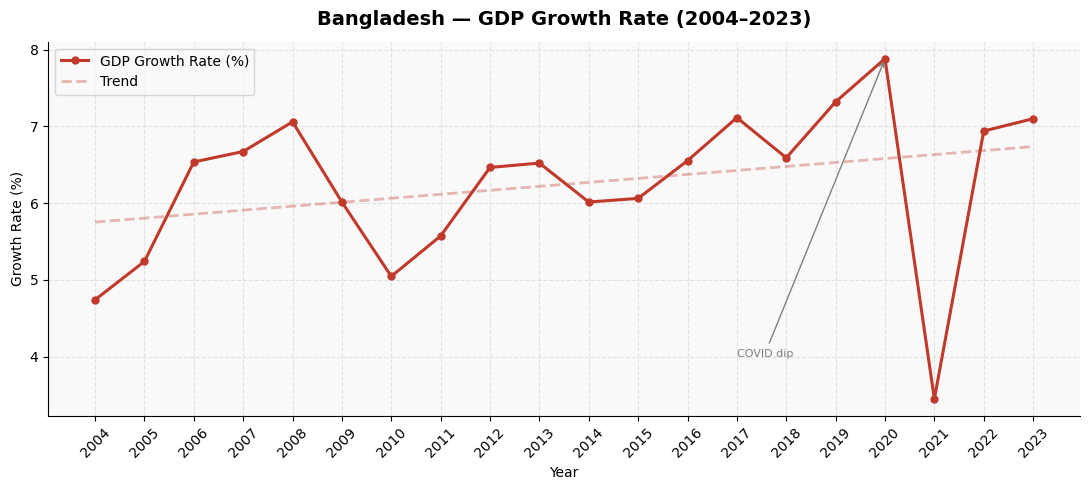

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(df['Year'], df['BGD_growth'], color=BGD_COLOR, linewidth=2.2,
        marker='o', markersize=5, label='GDP Growth Rate (%)')

# Trend line
z = np.polyfit(df['Year'], df['BGD_growth'], 1)
ax.plot(df['Year'], np.poly1d(z)(df['Year']),
        '--', color=BGD_COLOR, alpha=TREND_ALPHA, linewidth=2, label='Trend')

ax.annotate('COVID dip', xy=(2020, df.loc[df['Year']==2020,'BGD_growth'].values[0]),
            xytext=(2017, 4), fontsize=8, color='grey',
            arrowprops=dict(arrowstyle='->', color='grey', lw=1))

ax.set_title('Bangladesh — GDP Growth Rate (2004–2023)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Growth Rate (%)')
ax.set_xticks(df['Year'])
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('bgd_growth.png', dpi=150)
plt.show()

**Observation:** Bangladesh has maintained a remarkably stable growth rate of ~6–7% across two decades — one of the most consistent performers in South Asia. This is driven by RMG exports, remittances, and expanding domestic consumption.

---
## 4 — Bangladesh: Savings vs Capital Formation

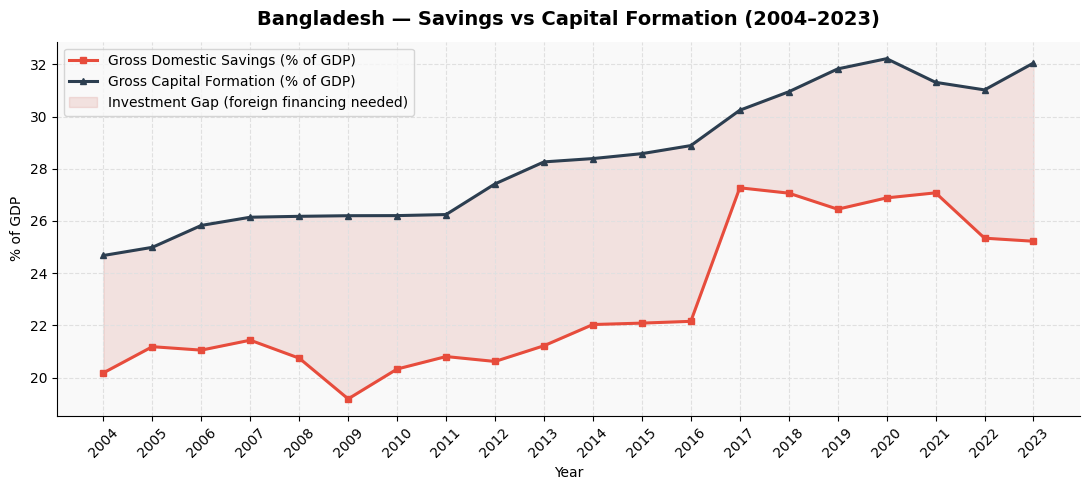

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(df['Year'], df['BGD_savings'], color=SAV_COLOR, linewidth=2.2,
        marker='s', markersize=5, label='Gross Domestic Savings (% of GDP)')
ax.plot(df['Year'], df['BGD_capital'], color=CAP_COLOR, linewidth=2.2,
        marker='^', markersize=5, label='Gross Capital Formation (% of GDP)')

ax.fill_between(df['Year'], df['BGD_savings'], df['BGD_capital'],
                where=df['BGD_capital'] > df['BGD_savings'],
                alpha=0.12, color=BGD_COLOR, label='Investment Gap (foreign financing needed)')

ax.set_title('Bangladesh — Savings vs Capital Formation (2004–2023)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('% of GDP')
ax.set_xticks(df['Year'])
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('bgd_cs.png', dpi=150)
plt.show()

**Observation:** Bangladesh's capital formation consistently exceeds domestic savings — this is the classic **savings gap** the Harrod-Domar model identifies in developing countries. The gap is bridged by remittances (~7% of GDP) and foreign aid/FDI.

---
## 5 — Side-by-Side Comparison: Growth Rates

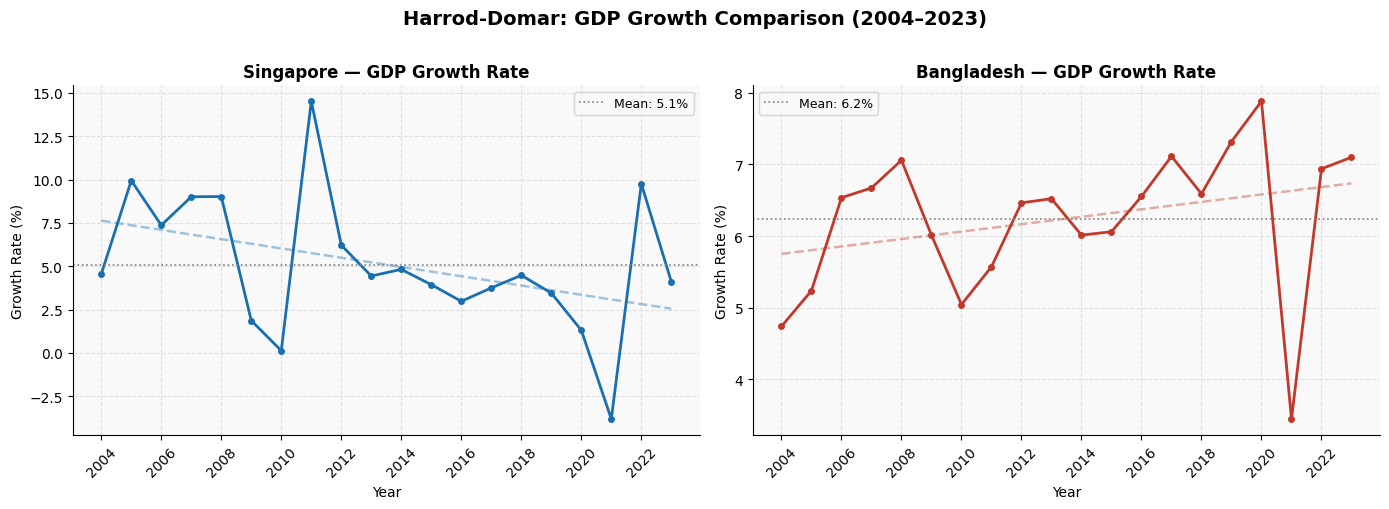

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, country, col, color, label in [
    (axes[0], 'Singapore', 'SGP_growth', SGP_COLOR, 'SGP Growth (%)'),
    (axes[1], 'Bangladesh', 'BGD_growth', BGD_COLOR, 'BGD Growth (%)'),
]:
    ax.plot(df['Year'], df[col], color=color, linewidth=2, marker='o', markersize=4)
    z = np.polyfit(df['Year'], df[col], 1)
    ax.plot(df['Year'], np.poly1d(z)(df['Year']), '--', color=color, alpha=0.4, linewidth=1.8)
    ax.axhline(df[col].mean(), color='grey', linestyle=':', linewidth=1.2,
               label=f'Mean: {df[col].mean():.1f}%')
    ax.set_title(f'{country} — GDP Growth Rate', fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Growth Rate (%)')
    ax.set_xticks(df['Year'][::2])
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)

fig.suptitle('Harrod-Domar: GDP Growth Comparison (2004–2023)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('comparison_growth.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6 — Combined Chart: Both Countries on One Axis

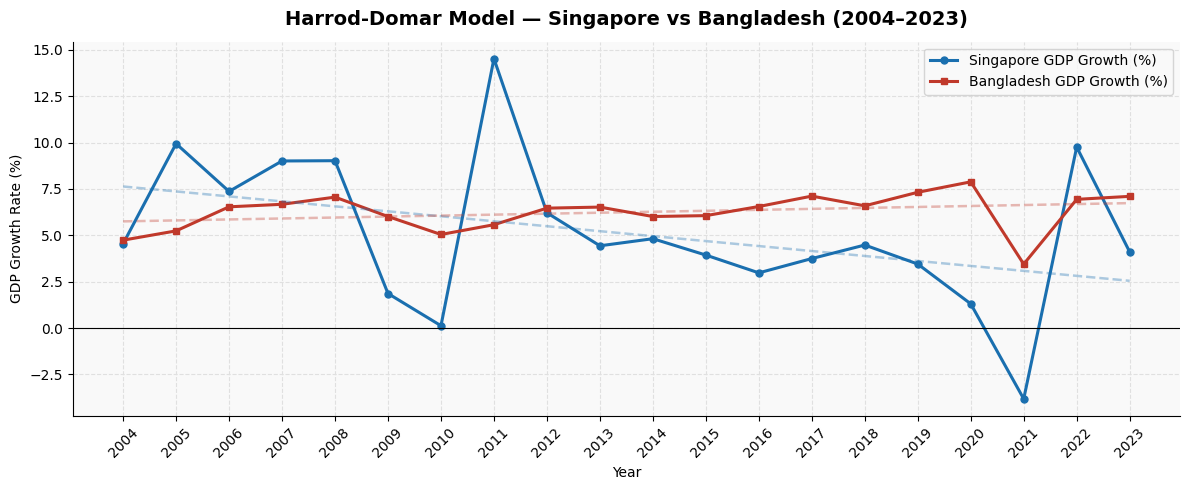

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df['Year'], df['SGP_growth'], color=SGP_COLOR, linewidth=2.2,
        marker='o', markersize=5, label='Singapore GDP Growth (%)')
ax.plot(df['Year'], df['BGD_growth'], color=BGD_COLOR, linewidth=2.2,
        marker='s', markersize=5, label='Bangladesh GDP Growth (%)')

for col, color in [('SGP_growth', SGP_COLOR), ('BGD_growth', BGD_COLOR)]:
    z = np.polyfit(df['Year'], df[col], 1)
    ax.plot(df['Year'], np.poly1d(z)(df['Year']),
            '--', color=color, alpha=TREND_ALPHA, linewidth=1.8)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Harrod-Domar Model — Singapore vs Bangladesh (2004–2023)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('GDP Growth Rate (%)')
ax.set_xticks(df['Year'])
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('combined_growth.png', dpi=150)
plt.show()

---
## 7 — Summary Statistics

In [18]:
summary = pd.DataFrame({
    'Metric': [
        'Avg GDP Growth (%)',
        'Avg Savings (% GDP)',
        'Avg Capital Formation (% GDP)',
        'Savings > Capital? (surplus/deficit)',
        'Growth Volatility (std dev)',
    ],
    'Singapore': [
        f"{df['SGP_growth'].mean():.2f}%",
        f"{df['SGP_savings'].mean():.2f}%",
        f"{df['SGP_capital'].mean():.2f}%",
        'Surplus (saves more than invests domestically)',
        f"{df['SGP_growth'].std():.2f}%",
    ],
    'Bangladesh': [
        f"{df['BGD_growth'].mean():.2f}%",
        f"{df['BGD_savings'].mean():.2f}%",
        f"{df['BGD_capital'].mean():.2f}%",
        'Deficit (relies on foreign capital)',
        f"{df['BGD_growth'].std():.2f}%",
    ]
})

print(summary.to_string(index=False))

                              Metric                                      Singapore                          Bangladesh
                  Avg GDP Growth (%)                                          5.09%                               6.24%
                 Avg Savings (% GDP)                                         53.24%                              22.92%
       Avg Capital Formation (% GDP)                                         25.25%                              28.38%
Savings > Capital? (surplus/deficit) Surplus (saves more than invests domestically) Deficit (relies on foreign capital)
         Growth Volatility (std dev)                                          4.06%                               1.03%


---
## 8 — Key Findings

### Singapore
- High savings rate (~53% of GDP) far exceeds domestic capital formation (~25%), creating a **savings surplus** — consistent with Harrod-Domar's prediction that high savings drive growth potential.
- Growth is **volatile** but trending upward, heavily tied to global trade cycles.
- Efficient capital utilization (low capital-output ratio) drives a higher warranted growth rate.

### Bangladesh
- Domestic savings **fall short** of capital formation — the classic Harrod-Domar **savings gap**. Bangladesh bridges this via remittances and FDI.
- Growth is **stable and consistent** at ~6–7%, driven by RMG exports and domestic consumption.
- Improving capital efficiency is key to accelerating growth further.

### Comparison
- Singapore's growth is **higher but more volatile**; Bangladesh's is **lower but more stable**.
- Harrod-Domar explains Singapore's edge through its **high savings-to-capital ratio**.
- For Bangladesh, the model recommends **closing the savings gap** and improving capital productivity.

---
*Data: World Bank Open Data | Analysis: Harrod-Domar Framework*